In [3]:
seed = 123 # random state seed

import pandas as pd
import requests
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

##############################################################################
#
# Return only one month from `data/` dircectory.
#
# <https://studres.cs.st-andrews.ac.uk/ID5059/Coursework/P2/data/>
# <https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page>
def read_single_month(month=1):
    path = f"../../data/nyc_taxi_2024-{month:02d}.csv"
    df = pd.read_csv(
        path, 
        parse_dates = ["tpep_pickup_datetime", "tpep_dropoff_datetime"],
        dtype = {"store_and_fwd_flag": str}
    )
    return df

##############################################################################
#
# Read all 12 csvs into 1 dataframe
#
# `nyc_taxi_2024-*.csv` & `taxi_zone_lookup.csv` expected in the `data/` directory
#
# <https://studres.cs.st-andrews.ac.uk/ID5059/Coursework/P2/data/>
# <https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page>
def raw(month_start=1, month_end=2):
    df = pd.DataFrame() # Empty, base df

    # `month_end+1` because the loop stops 1 before end
    for month in range(month_start, month_end+1):
        tmp = read_single_month(month=month)
        df = pd.concat([df, tmp], ignore_index=True) 

    return df

# Optional: time of day label (useful for report visualisations)
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 10:
        return "Morning Rush"
    elif 10 <= hour < 16:
        return "Midday"
    elif 16 <= hour < 20:
        return "Evening Rush"
    else:
        return "Evening"

##############################################################################
#
# Transformed version of the dataset, but still **unaggregated**.
#
# 1. cleans dataset for: invalid fares, invalid distances, where pickup is after dropoff
#    and missing pickup items
#
# 2. transforms:
#   a. timeperiod aggregates (what hour, day, week, etc.)
#   b. change `store_and_fwd_flag` from {'Y', 'N'} -> True/False
#   c. real `ratecode` from ID
#   d. real `payment_type` from ID
#   e. real `vendor` from ID
#   f. real `taxi zone` from ID (both pickup zone & dropoff zone)
#   g. real `service zone` from ID (more abstract version of `taxi zone`)
#   h. include `route` taken, i.e. string of `pickup zone` + `dropoff zone`
#   i. same as (h.), but for service zones, as well
#
# 3. drop ID columns
#
# 4. typecast all `object` types -> `category` (expect `store_and_fwd_flag`, which
#    is a boolean)
def clean_single_month(month=1):
    # df = raw(month_start=month_start, month_end=month_end)
    df = read_single_month(month=month)

    # ----------------------------------------------------------------------------#

    ### CLEANING

    # Removing rows with invalid fares (negative or zero fare amounts don't make sense)
    df = df[df["fare_amount"] > 0]

    # Remove rows with invalid trip distances
    df = df[df["trip_distance"] > 0]

    # Remove rows where pickup is after dropoff (data error)
    df = df[df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]]

    # Remove any rows with missing pickup times
    df = df.dropna(subset=["tpep_pickup_datetime"])

    # ----------------------------------------------------------------------------#

    ### TRANSFORMATIONS
    #
    # Time aggregates
    df['pickup_date'] = pd.to_datetime(df['tpep_pickup_datetime'].dt.date)
    df['pickup_hr'] = df['tpep_pickup_datetime'].dt.hour
    df['time_of_day'] = df['tpep_pickup_datetime']
    df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
    df['pickup_dow'] = df['tpep_pickup_datetime'].dt.weekday
    df['pickup_week'] = df['tpep_pickup_datetime'].dt.isocalendar().week
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
    df['pickup_year'] = df['tpep_pickup_datetime'].dt.year
    df["time_of_day"] = df["tpep_pickup_datetime"].dt.hour.apply(get_time_of_day)

    # # Never used these in the end
    #
    # df['dropoff_hr'] = df['tpep_dropoff_datetime'].dt.hour
    # df['dropoff_day'] = df['tpep_dropoff_datetime'].dt.day
    # df['dropoff_dow'] = df['tpep_dropoff_datetime'].dt.weekday
    # df['dropoff_week'] = df['tpep_dropoff_datetime'].dt.isocalendar().week
    # df['dropoff_month'] = df['tpep_dropoff_datetime'].dt.month
    # df['dropoff_year'] = df['tpep_dropoff_datetime'].dt.year

    # store_and_fwd_flag
    #
    # This flag indicates whether the trip record was held in vehicle memory before
    # sending to the vendor, aka “store and forward,” because the vehicle did not
    # have a connection to the server.
    # Y = store and forward trip
    # N = not a store and forward trip
    #
    # Change flag from 'Y' or 'N' -> True or False
    df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': True, 'N': False})

    # RatecodeID
    #
    # The final rate code in effect at the end of the trip.
    # 1 = Standard rate
    # 2 = JFK
    # 3 = Newark
    # 4 = Nassau or Westchester
    # 5 = Negotiated fare
    # 6 = Group ride
    # 99 = Null/unknown
    # ratecode_mapping = {
    #     1: "Standard Rate",
    #     2: "JFK",
    #     3: "Newark",
    #     4: "Nassua or Westchester",
    #     5: "Negotiated fare",
    #     6: "Group Ride",
    #     99: "Null/unknown",
    # }
    # df['ratecode'] = df['RatecodeID'].map(ratecode_mapping)

    # payment_type
    #
    # A numeric code signifying how the passenger paid for the trip.
    # 0 = Flex Fare trip
    # 1 = Credit card
    # 2 = Cash
    # 3 = No charge
    # 4 = Dispute
    # 5 = Unknown
    # 6 = Voided trip
    # payment_type_mapping = {
    #     0: "Flex Fare trip",
    #     1: "Credit card",
    #     2: "Cash",
    #     3: "No charge",
    #     4: "Dispute",
    #     5: "Unknown",
    #     6: "Voided trip",
    # }
    # df['payment_type'] = df['payment_type'].map(payment_type_mapping)

    # VendorID
    #
    # A code indicating the TPEP provider that provided the record.
    # 1 = Creative Mobile Technologies, LLC
    # 2 = Curb Mobility, LLC
    # 6 = Myle Technologies Inc
    # 7 = Helix
    # vendor_mapping = {
    #     1: "Creative Mobile Technologies, LLC",
    #     2: "Curb Mobility, LLC",
    #     6: "Myle Technologies Inc",
    #     7: "Helix",
    # }
    # df['vendor'] = df['VendorID'].map(vendor_mapping)    

    # Taxi zones
    #
    # .csv file needed to lookup codes
    zones = pd.read_csv("../../data/taxi_zone_lookup.csv")
    manhattan_ids = zones[zones["Borough"] == "Manhattan"]["LocationID"].tolist()

    # Taxi zones: Pickup zone & pickup service zone
    df = df[df["PULocationID"].isin(manhattan_ids)]
    df = df.merge(
        zones[['LocationID', 'Zone', 'service_zone']].rename(columns={
            'Zone': 'pickup_zone',
            # 'service_zone': 'pickup_service_zone',
        }),
        left_on='PULocationID', 
        right_on='LocationID',
        how='left'
    )
    df = df.drop(columns=['LocationID'])

    # Taxi zones: Dropoff zone & dropoff service zone
    df = df.merge(  
        zones[['LocationID', 'Zone', 'service_zone']].rename(columns={
            'Zone': 'dropoff_zone',
            # 'service_zone': 'dropoff_service_zone',
        }),
        left_on='DOLocationID', 
        right_on='LocationID',
        how='left'
    )
    df = df.drop(columns=['LocationID'])

    # Taxi zones: route taken
    df['route'] = df['pickup_zone'].astype(str) + " to " + df['dropoff_zone'].astype(str)
    # df['service_route'] = df['pickup_service_zone'].astype(str) + " to " + df['dropoff_service_zone'].astype(str)

    # ----------------------------------------------------------------------------#

    ### DROP COLUMNS
    columns_to_drop = [
        'RatecodeID',
        'VendorID',
        'PULocationID',
        'DOLocationID',
        'store_and_fwd_flag',
    ]
    df = df.drop(columns=columns_to_drop)


    ### TYPE CAST
    df = df.astype({
        # 'store_and_fwd_flag': 'bool',
        # 'payment_type': 'category',
        # 'ratecode': 'category',
        # 'vendor': 'category',
        'pickup_zone': 'category',
        # 'pickup_service_zone': 'category',
        'dropoff_zone': 'category',
        # 'dropoff_service_zone': 'category',
        'route': 'category',
        # 'service_route': 'category',
    })

    # Only 2024 data
    df = df[df['pickup_year'] == 2024]

    return df


##############################################################################
#
# Documentation:
#     <https://mesonet.agron.iastate.edu/nws/cf6table.php?station=KNYC&opt=bystation&year=2024>
#
# The API specifically calls:
#     <https://mesonet.agron.iastate.edu/json/cf6.py?station=KNYC&year=2024>
#
def read_weather_data():
    # Using new API
    response = requests.get("https://mesonet.agron.iastate.edu/json/cf6.py?station=KNYC&year=2024").json()
    wthr = pd.DataFrame(response['results'])
    wthr['date'] = pd.to_datetime(wthr['valid'])
    wthr = wthr.drop(columns=['name', 'station', 'valid', 'state', 'wfo', 'link', 'product', 'minutes_sunshine', 'possible_sunshine', 'hdd', 'cdd', 'gust_drct', 'avg_drct', 'snowd_12z', 'avg_smph'])

    # CF6 Code	Abbrev	Meaning
    # 1	FG	Fog or Mist
    # 2	DNSEFG	Fog or Vis 0.25 mile or less
    # 3	TS	Thunder
    # 4	IP	Ice pellets
    # 5	GR	Hail
    # 6	FZRA	Freezing Rain or Drizzle
    # 7	DSTSTM	Duststorm or Sandstorm vis 0.25 mile or less
    # 8	HZ	Smoke or Haze
    # 9	BLSN	Blowing Snow
    # X	TOR	Tornado
    # M	M	Missing Data
    wthr['fog']           = wthr['wxcodes'].str.contains('1', na=False).astype(bool)
    wthr['low_vis']       = wthr['wxcodes'].str.contains('2', na=False).astype(bool)
    wthr['thunder']       = wthr['wxcodes'].str.contains('3', na=False).astype(bool)
    wthr['ice']           = wthr['wxcodes'].str.contains('4', na=False).astype(bool)
    wthr['hail']          = wthr['wxcodes'].str.contains('5', na=False).astype(bool)
    wthr['freezing_rain'] = wthr['wxcodes'].str.contains('6', na=False).astype(bool)
    wthr['duststorm']     = wthr['wxcodes'].str.contains('7', na=False).astype(bool)
    wthr['haze']          = wthr['wxcodes'].str.contains('8', na=False).astype(bool)
    wthr['blowing_snow']  = wthr['wxcodes'].str.contains('9', na=False).astype(bool)
    wthr['tornado']       = wthr['wxcodes'].str.contains('X', na=False).astype(bool)

    # A lot of numerical values can include 'T' as an entry
    #
    # This refers to 'trace amounts', i.e. miniscule levels of precipitation; we will just replace with 0
    wthr.replace('T', 0, inplace=True)
    wthr.replace('M', np.nan, inplace=True)
    wthr = wthr.infer_objects(copy=False)
    wthr = wthr.astype({
        'snow': 'float64',
        'precip': 'float64',
    })

    wthr = wthr.drop(columns=[
        'wxcodes', # redundant
        'ice', # empty
        'tornado', # empty
        'blowing_snow', # empty
        'duststorm', # empty
        'avg_temp', # using 'high'
        'dep_temp', # using 'high'
        'low', # using 'high'
        'gust_smph', # using 'max_smph'
    ])

    wthr = wthr.rename(columns={
        'high': 'temp_high',
        'max_smph': 'max_wind_speed',
        'cloud_ss': 'cloud_coverage',
    })

    # impute 3 missing 'max_wind_speed' values
    wthr['max_wind_speed'] = wthr['max_wind_speed'].interpolate(method='linear')

    return wthr

##############################################################################
#
# Source: <https://www.officeholidays.com/countries/usa/new-york/2024>
#
# | Date | Holiday Name | Holiday Type |
# |------|--------------|--------------|
# | 01/01/2024 | New Year's Day | National |
# | 15/01/2024 | Martin Luther King Jr. Day | National |
# | 12/02/2024 | Lincoln's Birthday | Government |
# | 19/02/2024 | Washington's Birthday | Regional |
# | 31/03/2024 | Easter Sunday | Not a holiday |
# | 12/05/2024 | Mother's Day | Not a holiday |
# | 27/05/2024 | Memorial Day | National |
# | 16/06/2024 | Father's Day | Not a holiday |
# | 19/06/2024 | Juneteenth | Regional |
# | 04/07/2024 | Independence Day | National |
# | 02/09/2024 | Labor Day | National |
# | 14/10/2024 | Columbus Day | Regional |
# | 05/11/2024 | Election Day | Government |
# | 11/11/2024 | Veterans Day | Regional |
# | 28/11/2024 | Thanksgiving | National |
# | 25/12/2024 | Christmas Day | National |
def read_calendar_data():
    data = {
        "date": [
            "01/01/2024", "15/01/2024", "12/02/2024", "19/02/2024",
            "31/03/2024", "12/05/2024", "27/05/2024", "16/06/2024",
            "19/06/2024", "04/07/2024", "02/09/2024", "14/10/2024",
            "05/11/2024", "11/11/2024", "28/11/2024", "25/12/2024"
        ],
        "holiday": [
            "New Year's Day", "Martin Luther King Jr. Day", "Lincoln's Birthday",
            "Washington's Birthday", "Easter Sunday", "Mother's Day",
            "Memorial Day", "Father's Day", "Juneteenth", "Independence Day",
            "Labor Day", "Columbus Day", "Election Day", "Veterans Day",
            "Thanksgiving", "Christmas Day"
        ],
        "holiday_type": [
            "National", "National", "Government", "Regional", "Not a holiday",
            "Not a holiday", "National", "Not a holiday", "Regional", "National",
            "National", "Regional", "Government", "Regional", "National", "National"
        ]
    }

    calendar = pd.DataFrame(data)
    calendar["date"] = pd.to_datetime(calendar["date"], format="%d/%m/%Y")
    return calendar

##############################################################################
#
# For many months, clean, aggregated, and append monthly data.
groupings = [
    'pickup_month',
    'pickup_week', 
    # 'pickup_day',
    'pickup_date',
    'pickup_dow',
    # 'pickup_hr', 
    'time_of_day',
    # 'pickup_service_zone', 
    'pickup_zone',
    # 'dropoff_service_zone', 
    'dropoff_zone',
    'route',
    # 'service_route',
    # 'vendor', 
    # 'ratecode', 
    # 'payment_type',
    # 'store_and_fwd_flag'
]
def read_agg(month_start=1, month_end=2, groupings=groupings):
    base_df = pd.DataFrame()

    for month in range(month_start, month_end+1):
        print(f"reading data for month {month}")
        tmp_df = clean_single_month(month)
        # tmp_df = tmp_df[tmp_df['pickup_year'] == 2024]
        agg_df = tmp_df.groupby(groupings, as_index=False, observed=True).agg(
            total_ride_count        = ('tpep_pickup_datetime', 'count'), # count number of rides
            # total_passenger_count   = ('passenger_count', 'sum'),
            # avg_passenger_count     = ('passenger_count', 'mean'),
            # total_trip_distance     = ('trip_distance', 'sum'),
            # avg_trip_distance       = ('trip_distance', 'mean'),
            # total_fare_amount       = ('fare_amount', 'sum'),
            avg_fare_amount         = ('fare_amount', 'mean'),
            # total_extra             = ('extra', 'sum'),
            # avg_extra               = ('extra', 'mean'),
            # total_mta_tax           = ('mta_tax', 'sum'),
            # avg_mta_tax             = ('mta_tax', 'mean'),
            # total_tip_amount        = ('tip_amount', 'sum'),
            # avg_tip_amount          = ('tip_amount', 'mean'),
            # total_tolls_amount      = ('tolls_amount', 'sum'),
            # avg_tolls_amount        = ('tolls_amount', 'mean'),
            # total_impr_surcharge    = ('improvement_surcharge', 'sum'),
            # avg_impr_surcharge      = ('improvement_surcharge', 'mean'),
            # total_revenue           = ('total_amount', 'sum'),
            # avg_revenue             = ('total_amount', 'mean'),
            # total_airport_fee       = ('Airport_fee', 'sum'),
            # avg_airport_fee         = ('Airport_fee', 'mean'),
        )
        base_df = pd.concat([base_df, agg_df], ignore_index=True)

    print("collecting weather data")
    weather = read_weather_data()
    base_df = pd.merge(base_df, weather, left_on='pickup_date', right_on='date', how='left')
    base_df = base_df.drop(columns=['date'])

    print("collecting calendar data")
    cal = read_calendar_data()
    base_df = pd.merge(base_df, cal, left_on='pickup_date', right_on='date', how='left')
    base_df['holiday'] = base_df['holiday'].fillna("None")
    base_df = base_df.drop(columns=['date', 'holiday_type'])

    print("calculating lag demand")
    daily = base_df.groupby(['pickup_date', 'time_of_day', 'route'], as_index=False)['total_ride_count'].sum()
    daily = daily.sort_values(['route', 'time_of_day', 'pickup_date'])
    daily['lag_demand'] = daily.groupby(['route', 'time_of_day'])['total_ride_count'].shift(1)
    daily[daily['route'] == "Upper East Side North to Upper East Side South"]
    base_df = base_df.merge(
        daily[['route', 'pickup_date', 'time_of_day', 'lag_demand']],
        on=['time_of_day', 'route', 'pickup_date'],
        how='left'
    )
    base_df['lag_demand'] = base_df['lag_demand'].fillna(0)

    return base_df

In [5]:
df = read_agg(month_start=1, month_end=12)
df

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


<positron-console-cell-5>:299: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
<positron-console-cell-5>:300: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


collecting calendar data
calculating lag demand


,pickup_month,pickup_week,pickup_date,pickup_dow,time_of_day,pickup_zone,dropoff_zone,route,total_ride_count,avg_fare_amount,...,max_wind_speed,cloud_coverage,fog,low_vis,thunder,hail,freezing_rain,haze,holiday,lag_demand
0,1,1,2024-01-01,0,Evening,Alphabet City,Gramercy,Alphabet City to Gramercy,1,7.90,...,9.0,7.0,False,False,False,False,False,False,New Year's Day,0.0
1,1,1,2024-01-01,0,Evening,Alphabet City,Meatpacking/West Village West,Alphabet City to Meatpacking/West Village West,1,13.50,...,9.0,7.0,False,False,False,False,False,False,New Year's Day,0.0
2,1,1,2024-01-01,0,Evening,Alphabet City,Penn Station/Madison Sq West,Alphabet City to Penn Station/Madison Sq West,1,19.78,...,9.0,7.0,False,False,False,False,False,False,New Year's Day,0.0
3,1,1,2024-01-01,0,Evening,Alphabet City,Sutton Place/Turtle Bay North,Alphabet City to Sutton Place/Turtle Bay North,1,16.69,...,9.0,7.0,False,False,False,False,False,False,New Year's Day,0.0
4,1,1,2024-01-01,0,Evening,Alphabet City,TriBeCa/Civic Center,Alphabet City to TriBeCa/Civic Center,1,10.00,...,9.0,7.0,False,False,False,False,False,False,New Year's Day,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5128898,12,52,2024-12-29,6,Morning Rush,Yorkville West,West Chelsea/Hudson Yards,Yorkville West to West Chelsea/Hudson Yards,2,21.21,...,14.0,9.0,False,False,False,False,False,True,None,1.0
5128899,12,52,2024-12-29,6,Morning Rush,Yorkville West,West Concourse,Yorkville West to West Concourse,1,17.00,...,14.0,9.0,False,False,False,False,False,True,None,1.0
5128900,12,52,2024-12-29,6,Morning Rush,Yorkville West,Woodside,Yorkville West to Woodside,1,26.80,...,14.0,9.0,False,False,False,False,False,True,None,1.0
5128901,12,52,2024-12-29,6,Morning Rush,Yorkville West,Yorkville East,Yorkville West to Yorkville East,3,6.50,...,14.0,9.0,False,False,False,False,False,True,None,5.0


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

daily = df.groupby(['pickup_date'], as_index=False).agg(
    total_ride_count = ('total_ride_count', 'sum'),
    max_temp = ('temp_high', 'mean'),
    max_wind_speed = ('max_wind_speed', 'mean'),
    cloud_coverage = ('cloud_coverage', 'mean')
)
daily

,pickup_date,total_ride_count,max_temp,max_wind_speed,cloud_coverage
0,2024-01-01,63871,47.0,9.0,7.0
1,2024-01-02,61060,42.0,10.0,0.0
2,2024-01-03,68584,43.0,10.0,5.0
3,2024-01-04,89622,45.0,20.0,6.0
4,2024-01-05,90549,37.0,16.0,0.0
...,...,...,...,...,...
361,2024-12-27,69887,44.0,8.0,1.0
362,2024-12-28,73666,54.0,8.0,10.0
363,2024-12-29,64143,60.0,14.0,9.0
364,2024-12-30,66403,58.0,16.0,6.0


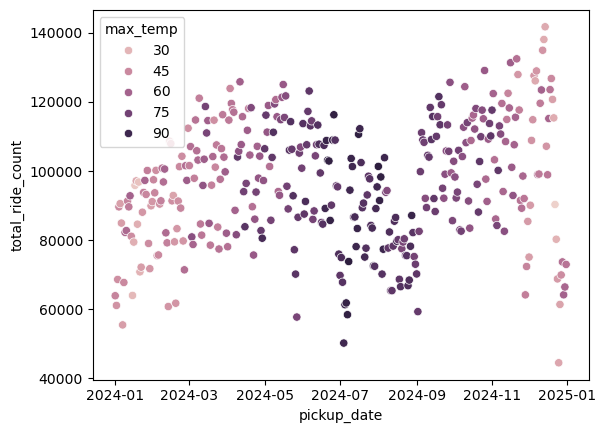

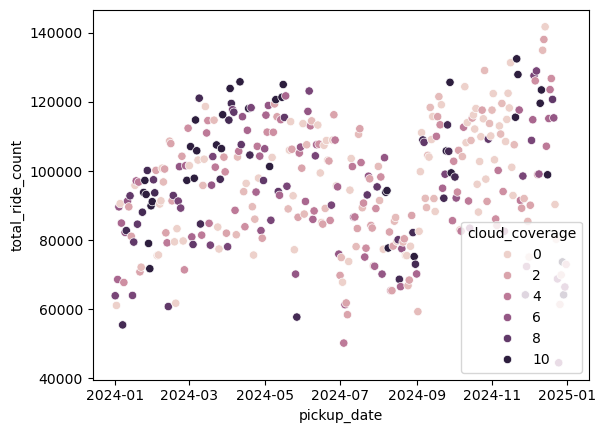

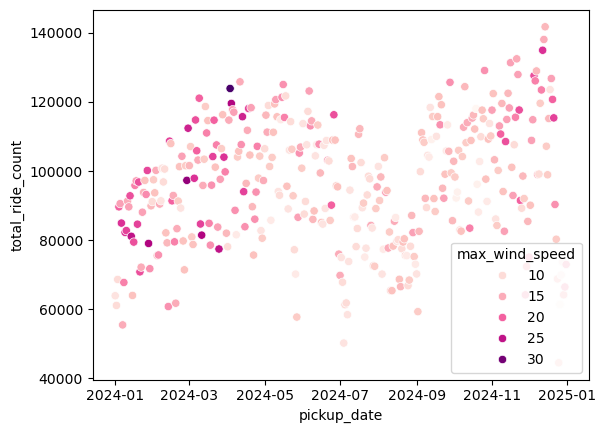

In [13]:
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='max_temp')
plt.show()

sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='cloud_coverage')
plt.show()

import numpy as np
# daily['log_wind_speed'] = np.log1p(daily['max_wind_speed'])
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='max_wind_speed', palette='RdPu')
plt.show()

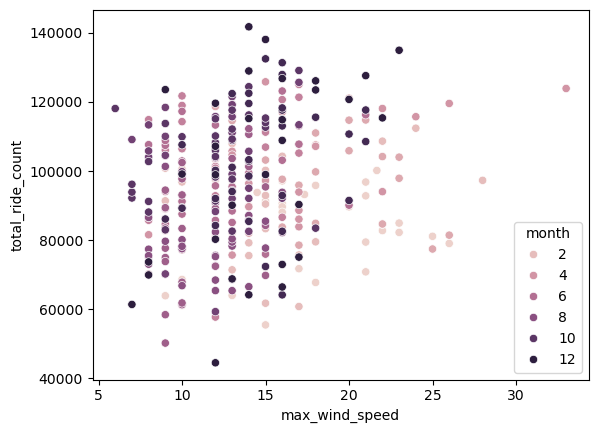

In [19]:
# Temperature
# sns.histplot(daily, x='max_temp')
# plt.show()

daily['month'] = daily['pickup_date'].dt.month
sns.scatterplot(daily, x='max_wind_speed', y='total_ride_count', hue='month')
plt.show()

In [ ]:
sns.histplot(daily, x='')

,pickup_date,total_ride_count,max_temp,max_wind_speed,cloud_coverage,scaled_temp
0,2024-01-01,63871,47.0,9.0,7.0,-1.050616
1,2024-01-02,61060,42.0,10.0,0.0,-1.342942
2,2024-01-03,68584,43.0,10.0,5.0,-1.284476
3,2024-01-04,89622,45.0,20.0,6.0,-1.167546
4,2024-01-05,90549,37.0,16.0,0.0,-1.635267
...,...,...,...,...,...,...
361,2024-12-27,69887,44.0,8.0,1.0,-1.226011
362,2024-12-28,73666,54.0,8.0,10.0,-0.641360
363,2024-12-29,64143,60.0,14.0,9.0,-0.290569
364,2024-12-30,66403,58.0,16.0,6.0,-0.407499


<Axes: >

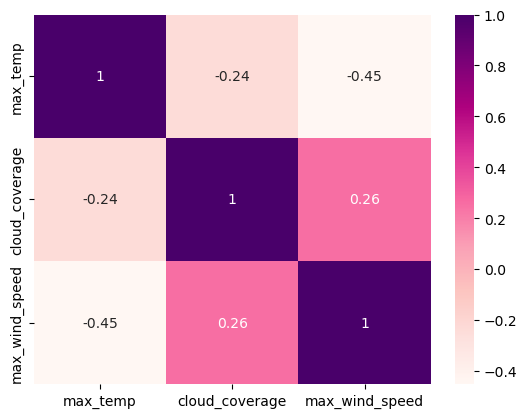

In [27]:
vars = ['max_temp', 'cloud_coverage', 'max_wind_speed']
corrMatrix = daily[vars].corr()

sns.heatmap(corrMatrix, annot=True, cmap='RdPu')

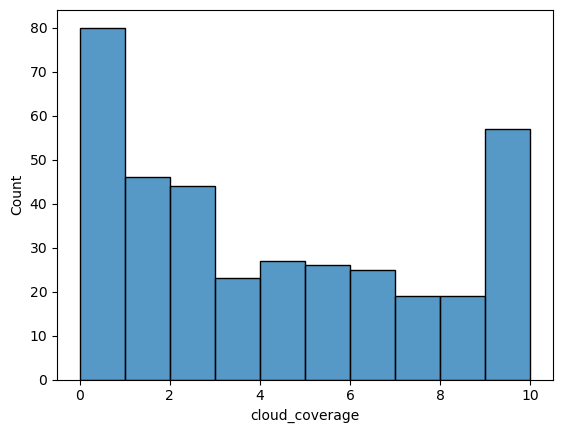

In [21]:
# Scaled temperature
sns.histplot(daily, x='cloud_coverage')
plt.show()

In [ ]:
routes = df.groupby(['route'], as_index=False).agg(
    total_ride_count = ('total_ride_count', 'sum')
)
# routes
routes(
    routes['total_ride_count'].sort_values(ascending=False).head(20)
)
# sns.barplot(routes, x='route', y='total_ride_count')
# plt.show()

TypeError: 'DataFrame' object is not callable